In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [19]:
base_dir = Path.cwd().parent
print(base_dir)
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

c:\Users\keyne\Documents\Market_Basket_Analysis


In [20]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days),
    margen = ('margenpesos', 'sum')
).reset_index()


# First sight to the distribution of my data

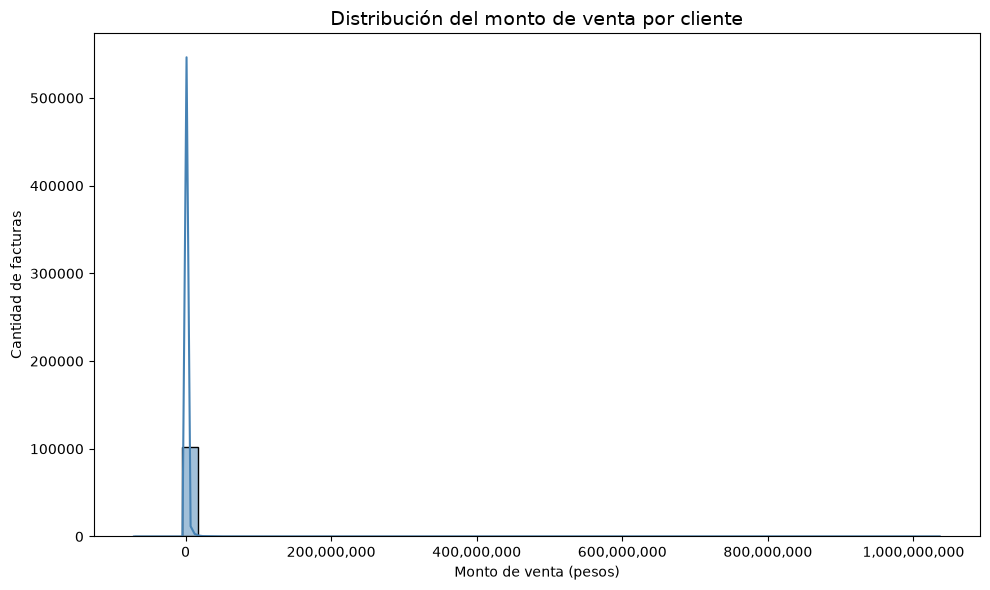

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [22]:
devoluciones = clientes[clientes['montoventapesos']<=0]
clientes_positivos = clientes[(clientes['montoventapesos']>0)&(clientes['margen']>0)]


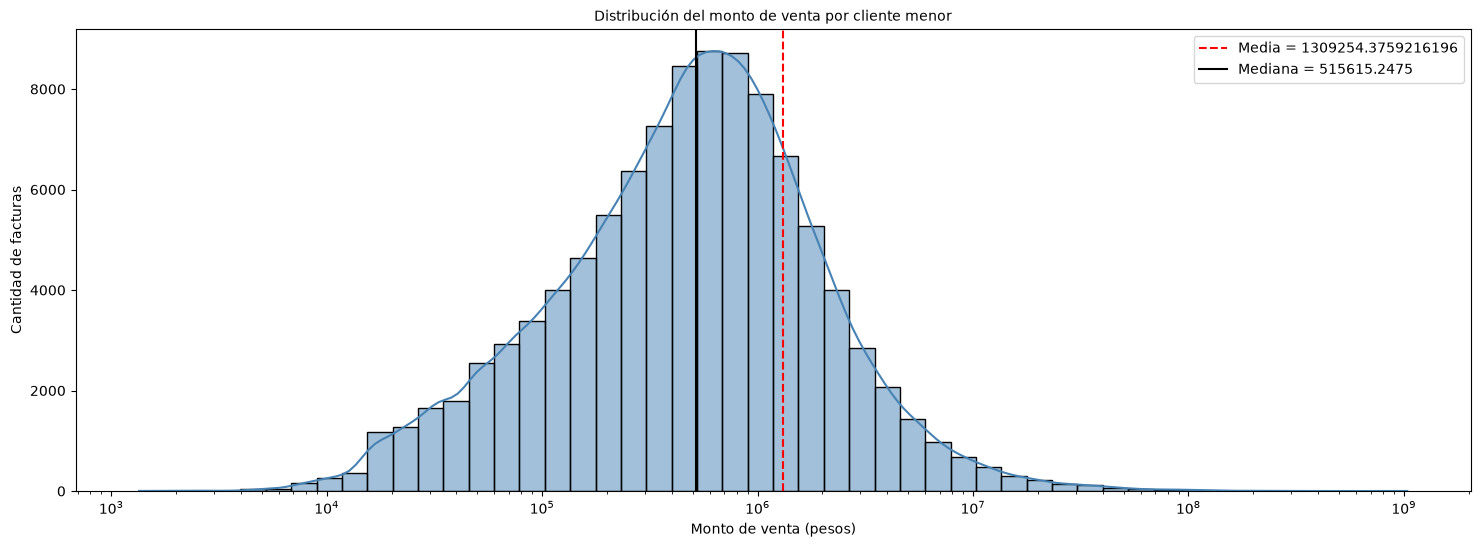

In [23]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

variables = ['frecuencia','recencia','montoventapesos']
preprocesador = ColumnTransformer(
    transformers=
    [
        ('reciente', MinMaxScaler(),['recencia']),
        ('historial',QuantileTransformer(output_distribution='normal'),['frecuencia']),
        ('monto', QuantileTransformer(output_distribution='normal'),['montoventapesos'])
    ]
)



x = clientes_positivos[variables]
x_scaled = preprocesador.fit_transform(x)

x_scaled[:,0] = x_scaled[:,0]*5
x_scaled[:,1] = x_scaled[:,1]*4
x_scaled[:,2] = x_scaled[:,2]*3
 


> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

clientes_positivos['pca1'] = x_pca[:,0]
clientes_positivos['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,-0.11,0.93,0.35
PCA2,-0.10,-0.36,0.93


<Axes: xlabel='pca1', ylabel='pca2'>

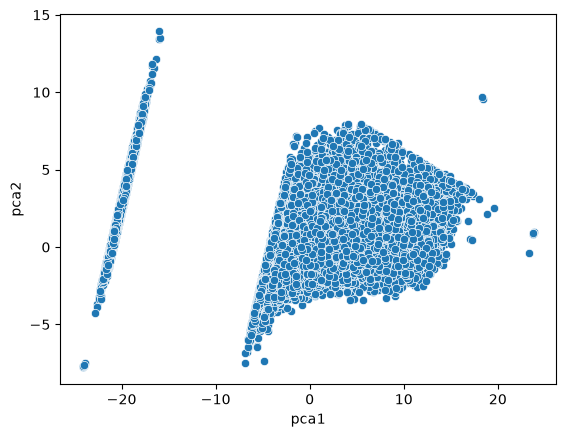

In [26]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=clientes_positivos,
    x=clientes_positivos['pca1'],
    y=clientes_positivos['pca2']
)

## ***Clustering***

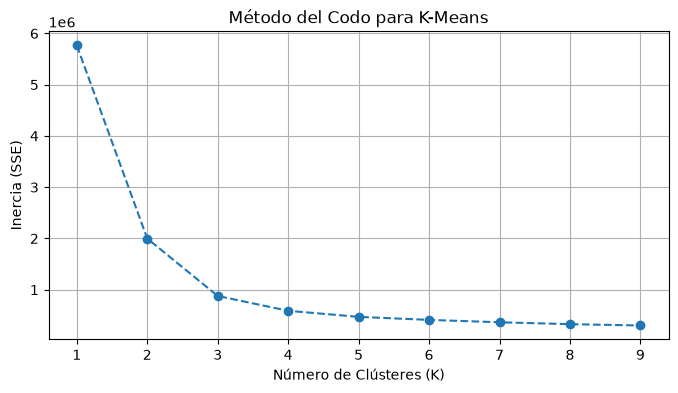

In [27]:
from sklearn.cluster import KMeans

inertia = []
rango = range(1,10)

valores = x_scaled
for i in rango:
    k_means = KMeans(n_clusters=i,random_state=42, n_init=10)
    k_means.fit(valores)
    inertia.append(k_means.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


> Para este tema use un **K_optimo = 3**

In [28]:
K_means= KMeans(n_clusters=3,random_state=42, n_init=1000).fit(valores)

datos = K_means.transform(valores)
print(K_means.cluster_centers_)
clientes_positivos['cluster'] = K_means.labels_

[[  1.21716371  -1.98991306  -1.50445884]
 [  2.79011862 -20.79735033  -5.01714414]
 [  0.2255117    3.50670111   2.55651294]]


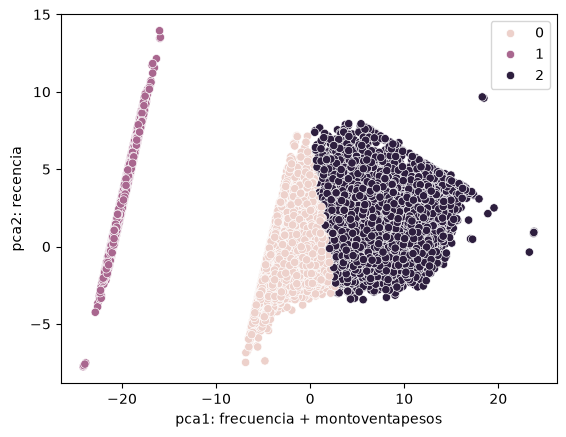

In [29]:
plt.Figure(figsize=(10,14))

sns.scatterplot(
    data=clientes_positivos,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia')
plt.legend(loc = 'upper right')


## **Merging clusters with the client historial and setting names of each one**

### ***Clusters Analysis***

This next step we start an analysis to see what are the features of each cluster to categorize them propertly 

#### ***Setting name of the clusters***

C:\Users\keyne\AppData\Local\Temp\ipykernel_18900\4192310848.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_18900\4192310848.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_18900\4192310848.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\keyne\AppData\Local\Temp\ipykernel_18900\4192310848.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

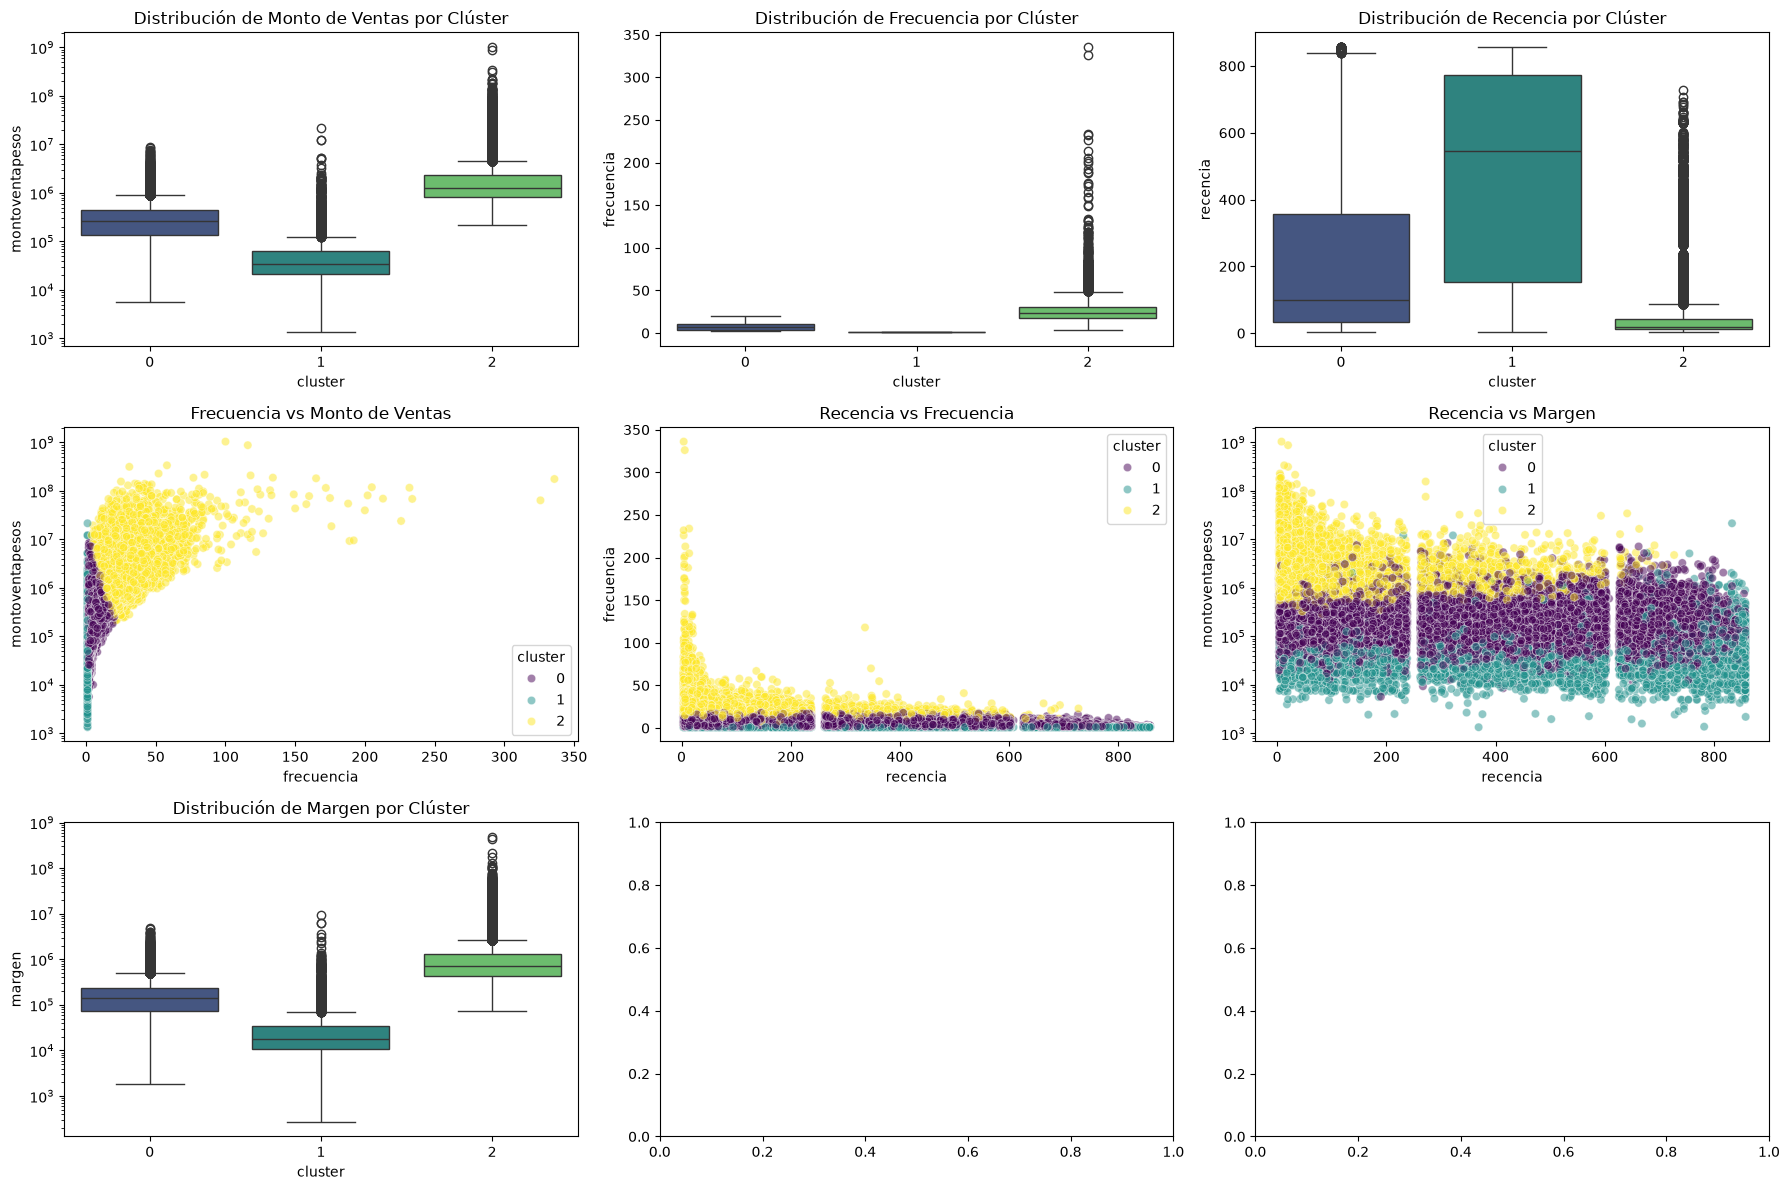

In [30]:
import matplotlib.ticker as ticker

# Crear una figura con múltiples subplots para analizar las dimensiones RFM por clúster
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

# 1. Boxplot de Monto de Ventas por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='montoventapesos', 
    ax=axes[0, 0], 
    palette='viridis'
)
axes[0, 0].set_title('Distribución de Monto de Ventas por Clúster')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[0,0].set_yscale('log')

# 2. Boxplot de Frecuencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='frecuencia', 
    ax=axes[0, 1], 
    palette='viridis'
)
axes[0, 1].set_title('Distribución de Frecuencia por Clúster')

# 3. Boxplot de Recencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='recencia', 
    ax=axes[0, 2], 
    palette='viridis'
)
axes[0, 2].set_title('Distribución de Recencia por Clúster')

# 4. Scatter Plot: Frecuencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
axes[1, 0].set_title('Frecuencia vs Monto de Ventas')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 0].set_yscale('log')

# 5. Scatter Plot: Recencia vs Frecuencia
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='frecuencia', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 1], 
    alpha=0.5
)
axes[1, 1].set_title('Recencia vs Frecuencia')

# 6. Scatter Plot: Recencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 2], 
    alpha=0.5
)
axes[1, 2].set_title('Recencia vs Margen')
axes[1, 2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 2].set_yscale('log')

sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='margen', 
    ax=axes[2,0], 
    palette='viridis'
)
axes[2,0].set_title('Distribución de Margen por Clúster')
axes[2,0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[2,0].set_yscale('log')

plt.tight_layout()
plt.show()

C:\Users\keyne\AppData\Local\Temp\ipykernel_18900\2841566347.py:1: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  sns.jointplot(


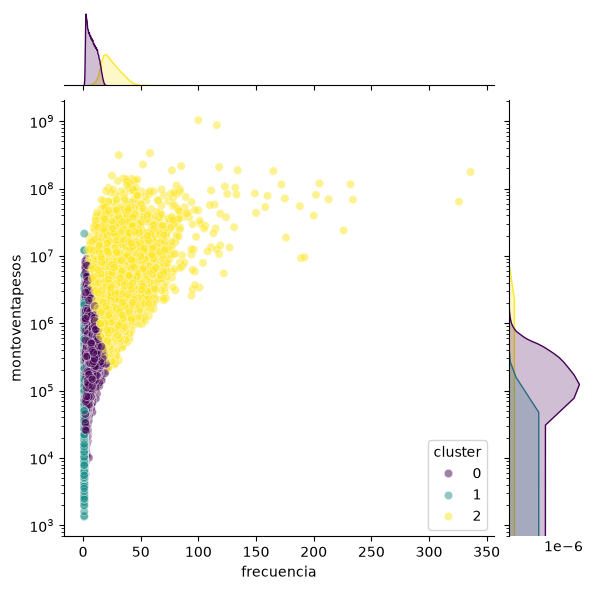

In [31]:
sns.jointplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    kind='scatter',
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
plt.yscale('log')


In [ ]:
def auto_nombrar_clusters(df_input):
    """We are using quantiles to categorize the clusters names here"""
    
    df = df_input.copy()

   
    p_rec_baja = df["recencia"].quantile(0.33) 
    p_rec_alta = df["recencia"].quantile(0.66)

    p_frec_alta = df["frecuencia"].quantile(0.75)
    p_frec_media = df["frecuencia"].quantile(0.40)

    p_monto_alto = df["montoventapesos"].quantile(0.75)
    p_monto_bajo = df["montoventapesos"].quantile(0.25)

    # Condition
    def asignar_etiqueta(row):
        rec = row["recencia"]
        frec = row["frecuencia"]
        monto = row["montoventapesos"]

        # Vip_clients
        if rec <= p_rec_baja and frec >= p_frec_alta and monto >= p_monto_alto:
            return "Champion VIP"

        elif rec <= p_rec_alta and frec >= p_frec_media:
            return "Loyal Clients"
        
        elif rec <= p_rec_baja and frec < p_frec_media:
            return "Promising / Recents"

        elif rec > p_rec_alta and frec >= p_frec_media:
            return "In Risk / To recover"
       
        elif rec > p_rec_alta and frec < p_frec_media:
            return "Inactives / Churn"

        else:
            return "Once in a while"

    # Applying the function
    df["nombre_cluster"] = df.apply(asignar_etiqueta, axis=1)

    return df

def 

# Reasinging the dataframe
clientes_positivos = auto_nombrar_clusters(clientes_positivos)

### ***Merging with the client history***

In [33]:
df_clientes = pd.merge(clientes_positivos[['cliente','cluster','nombre_cluster']],df, left_on='cliente', right_on='cliente', how='inner')

### ***Clients understanding***

I visualized every cluster with his own different color to see how they behave inside the clusters,and I found that they share the features that I actually want them to have.
As we can see the company has a very close group of clients which overlap specially on recency and frecuency but with a different purchase, and that is when this analysis takes action, in recognizing those clients that are different specially on the ***purchase***, 


In [34]:
resumen_clusters = clientes_positivos.groupby(['cluster','nombre_cluster']).agg(
    num_clientes = ('cliente', 'count'),
    recencia_min = ('recencia', 'min'),
    recencia_max = ('recencia', 'max'),
    recencia_median = ('recencia', 'median'),
    recencia_avg = ('recencia', 'mean'),
    frecuencia_min = ('frecuencia', 'min'),
    frecuencia_max = ('frecuencia', 'max'),
    frecuencia_median = ('frecuencia', 'median'),
    frecuencia_avg = ('frecuencia', 'mean'),
    monto_min = ('montoventapesos', 'min'),
    monto_max = ('montoventapesos', 'max'),
    monto_median = ('montoventapesos', 'median'),
    monto_avg = ('montoventapesos', 'mean'),
    margen_min = ('margen', 'min'),
    margen_max = ('margen', 'max'),
    margen_median = ('margen', 'median'),
    margen_avg = ('margen', 'mean')
).reset_index()

resumen_clusters

,cluster,nombre_cluster,num_clientes,recencia_min,recencia_max,recencia_median,recencia_avg,frecuencia_min,frecuencia_max,frecuencia_median,frecuencia_avg,monto_min,monto_max,monto_median,monto_avg,margen_min,margen_max,margen_median,margen_avg
0,0,In Risk / To recover,6112,103,797,229.00,279.02,9,20,11.00,11.49,"76,052.23","2,088,139.99","411,430.95","459,240.65","18,732.55","1,165,294.47","216,750.21","245,494.04"
1,0,Inactives / Churn,18455,103,858,411.00,424.15,2,8,4.00,4.36,"5,714.29","8,400,038.64","145,023.31","237,704.32","1,798.41","4,734,257.35","75,797.20","128,462.39"
2,0,Loyal Clients,13275,3,102,34.00,37.60,9,20,12.00,12.16,"82,731.27","1,650,979.82","413,076.04","453,561.41","33,448.97","1,096,891.31","218,181.37","244,286.94"
3,0,Once in a while,7552,24,102,53.00,55.48,2,8,5.00,5.12,"13,025.21","7,234,892.07","199,141.84","302,118.38","4,713.92","3,328,269.68","106,144.73","167,456.23"
4,0,Promising / Recents,4363,3,21,13.00,12.70,2,8,5.00,5.09,"16,134.45","8,999,970.00","216,453.39","325,811.77","2,530.98","3,803,624.56","116,936.23","183,516.28"
5,1,Inactives / Churn,6736,103,858,668.00,583.50,1,1,1.00,1.00,"1,344.54","21,484,578.90","31,932.80","75,596.90",266.24,"9,154,297.06","16,386.32","40,816.50"
6,1,Once in a while,1089,24,102,56.00,58.82,1,1,1.00,1.00,"4,853.00","2,160,000.00","41,243.72","79,714.48",997.90,"1,174,158.17","22,495.19","45,199.07"
7,1,Promising / Recents,508,3,21,12.00,12.24,1,1,1.00,1.00,"3,981.00","5,082,336.00","55,294.01","111,857.41",906.20,"2,484,818.56","30,404.95","62,783.65"
8,2,Champion VIP,12499,3,21,13.00,12.53,21,336,32.00,33.15,"1,170,492.68","1,036,088,953.70","2,377,954.39","4,963,639.84","236,878.59","491,067,982.92","1,328,817.99","2,789,921.32"
9,2,In Risk / To recover,3376,103,727,189.00,227.91,9,118,18.00,19.32,"226,878.66","155,754,642.27","1,137,510.62","2,020,928.95","91,278.35","71,851,726.80","620,166.94","1,113,821.75"


## ***Jobbing for the model***

In [35]:
import joblib

artefactos_modelo = {
    'preprocessor': preprocesador,
    'kmeans': k_means
}

joblib.dump(artefactos_modelo, 'modelo_clustering_rfm.pkl')

['modelo_clustering_rfm.pkl']

In [36]:
df_clientes.to_csv(f'{base_dir}/files/segmentos.csv')